<a href="https://colab.research.google.com/github/ChungyiBossi/2026_gjun_summer/blob/main/EDA%E8%88%87%E5%95%86%E6%A5%AD%E6%B1%BA%E7%AD%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3
from google.colab import drive
drive.mount('/content/drive')

# DB 檔案路徑
db_path = "/content/drive/MyDrive/工作/2026/巨匠北認-商業資料分析/data/raw/course.db"

# 用 `with` 語法管理連線，確保自動關閉。
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query("SELECT * FROM orders LIMIT 5", conn)
    display(df)

Mounted at /content/drive


,order_id,customer_id,order_date,status,payment_type
0,1,2323,2025-05-02,completed,wallet
1,2,117,2024-07-14,completed,wallet
2,3,160,2025-03-29,cancelled,card
3,4,1240,2024-07-08,completed,atm
4,5,714,2024-08-12,completed,atm


In [ ]:
def read_db(query):
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(query, conn)
        return df

# 0.商業資料分析總覽

1. **探索資料庫表格**: 識別 course.db 資料庫中所有可用的表格，以了解我們可以使用的資料的完整範圍。

2. **理解資料架構**:
    * 檢視相關表格的架構。
    * 顯示欄位名稱、資料類型。

3. **定義商業問題/目標:**
    * 制定清晰的商業問題或目標，並定義相關的名詞。
    * 「哪些是暢銷產品？」 -> 定義暢銷
    * 「銷售額隨時間的變化如何？」 -> 時間的範圍?

4. **識別關鍵指標/KPIs:**
    * 根據已定義的商業問題，確定將用於衡量進度、績效或回答問題的關鍵績效指標 (KPIs)

5. **資料預處理:**
    * 處理缺失值
    * 轉換資料類型
    * 清理不一致的條目

6. **執行探索性資料分析 (EDA)**:
    * 進行初步的探索性資料分析，利用摘要統
    * 基本視覺化來發現趨勢與關係。

7. **視覺化關鍵洞察:**
    * 以圖形有效地傳達從分析中獲得的關鍵洞察和發現。
    * 佐以簡短的文字與KPI數據，傳達你的洞察與發現。

8. **Final Task**: 根據商業資料分析，總結關鍵發現、結論和潛在建議，以回答最初的商業問題或目標。

# 1.探索資料庫表格

In [ ]:
query = '''
SELECT name
FROM sqlite_master
WHERE type = 'table'
'''

read_db(query)

,name
0,customers
1,products
2,orders
3,order_items
4,sessions
5,events
6,ab_assignments


In [ ]:
read_db("SELECT * FROM sqlite_master")

,type,name,tbl_name,rootpage,sql
0,table,customers,customers,2,"CREATE TABLE customers (customer_id INTEGER, s..."
1,table,products,products,28,"CREATE TABLE products (product_id INTEGER, cat..."
2,table,orders,orders,29,"CREATE TABLE orders (order_id INTEGER, custome..."
3,table,order_items,order_items,237,"CREATE TABLE order_items (order_id INTEGER, pr..."
4,table,sessions,sessions,448,"CREATE TABLE sessions (session_id INTEGER, cus..."
5,table,events,events,1353,"CREATE TABLE events (event_id INTEGER, session..."
6,table,ab_assignments,ab_assignments,3853,CREATE TABLE ab_assignments (customer_id INTEG...


In [ ]:
query = '''
SELECT *
FROM order_items;
'''
read_db(query)

,order_id,product_id,quantity,unit_price,discount_rate
0,1,28,1,567,0.05
1,2,2,1,3850,0.05
2,2,18,1,778,0.10
3,3,19,1,2193,0.00
4,3,36,1,1580,0.15
...,...,...,...,...,...
39622,21997,36,2,1580,0.00
39623,21998,16,1,1002,0.05
39624,21999,29,1,2320,0.05
39625,22000,27,1,1579,0.00


In [ ]:
import re

# Fetch table names and their CREATE TABLE statements from sqlite_master
query_tables_sql = "SELECT name, sql FROM sqlite_master WHERE type = 'table'"
tables_df = read_db(query_tables_sql)

output_text = ""

# Iterate through each table to extract its schema
for index, row in tables_df.iterrows():
    table_name = row['name']
    create_table_sql = row['sql']

    output_text += f"Table: {table_name}\n"

    # Extract content within parentheses for column definitions
    match = re.search(r'\((.*)\)', create_table_sql)
    if match:
        columns_str = match.group(1)
        # Split by comma, considering potential nested parentheses for constraints if any
        # A simpler split works for the given schema structure
        column_definitions = [col.strip() for col in columns_str.split(',')]

        for col_def in column_definitions:
            # Split column definition into name and type, handling cases like 'col_name TYPE PRIMARY KEY'
            parts = col_def.split(' ', 1)
            col_name = parts[0]
            col_type = parts[1] if len(parts) > 1 else ""
            output_text += f"- {col_name} ({col_type})\n"
    output_text += "\n"

print(output_text)


Table: customers
- customer_id (INTEGER)
- signup_date (TEXT)
- acquisition_channel (TEXT)
- city (TEXT)
- segment (TEXT)

Table: products
- product_id (INTEGER)
- category (TEXT)
- unit_price (INTEGER)

Table: orders
- order_id (INTEGER)
- customer_id (INTEGER)
- order_date (TEXT)
- status (TEXT)
- payment_type (TEXT)

Table: order_items
- order_id (INTEGER)
- product_id (INTEGER)
- quantity (INTEGER)
- unit_price (INTEGER)
- discount_rate (REAL)

Table: sessions
- session_id (INTEGER)
- customer_id (INTEGER)
- session_start (TEXT)
- device (TEXT)
- traffic_source (TEXT)
- campaign (TEXT)
- experiment_group (TEXT)

Table: events
- event_id (INTEGER)
- session_id (INTEGER)
- event_type (TEXT)
- event_time (TEXT)
- order_id (INTEGER)
- revenue (REAL)

Table: ab_assignments
- customer_id (INTEGER)
- experiment_group (TEXT)
- assign_date (TEXT)




# 2.理解資料架構

> 假設我們是第一次看到這筆資料，最好紀錄此DB每個TABLE，以及TABLE每個欄位

> 用現成的工具製作關聯圖：如Draw.io繪製

## 2-1.檢查表格資料


*   完整性（Completeness）
*   唯一性（Uniqueness）
*   一致性（Consistency）
*   合理性（Reasonableness）




In [ ]:
query = '''
SELECT *
FROM sessions;
'''
session_df = read_db(query)
session_df

,session_id,customer_id,session_start,device,traffic_source,campaign,experiment_group
0,1,2473,2025-08-14T11:02,desktop,sem,none,B
1,2,2155,2024-02-29T11:56,mobile,sem,retarget,A
2,3,2437,2024-11-13T16:23,mobile,sem,none,B
3,4,164,2024-04-22T16:15,mobile,email,retarget,B
4,5,1604,2024-06-15T08:39,desktop,direct,none,A
...,...,...,...,...,...,...,...
69995,69996,1747,2025-06-05T21:47,desktop,sem,none,B
69996,69997,1688,2024-08-07T08:03,mobile,seo,none,B
69997,69998,1217,2024-08-07T16:46,mobile,social,none,B
69998,69999,1863,2025-12-18T16:17,mobile,email,double11,B


In [ ]:
session_df.info() # <-- 看似非常完美

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   session_id        70000 non-null  int64 
 1   customer_id       70000 non-null  int64 
 2   session_start     70000 non-null  object
 3   device            70000 non-null  object
 4   traffic_source    70000 non-null  object
 5   campaign          70000 non-null  object
 6   experiment_group  70000 non-null  object
dtypes: int64(2), object(5)
memory usage: 3.7+ MB


In [ ]:
# 顯示每一欄位的唯一值集合，確定每個欄位有哪些欄位值
for col in session_df.columns:
    unique_vals = session_df[col].unique()
    print(f"欄位 '{col}' 的唯一值 ({len(unique_vals)} 個):")
    print(unique_vals)
    print("-" * 30)

欄位 'session_id' 的唯一值 (70000 個):
[    1     2     3 ... 69998 69999 70000]
------------------------------
欄位 'customer_id' 的唯一值 (2500 個):
[2473 2155 2437 ...  725  774 1569]
------------------------------
欄位 'session_start' 的唯一值 (67778 個):
['2025-08-14T11:02' '2024-02-29T11:56' '2024-11-13T16:23' ...
 '2024-08-07T16:46' '2025-12-18T16:17' '2025-12-30T03:46']
------------------------------
欄位 'device' 的唯一值 (3 個):
['desktop' 'mobile' 'tablet']
------------------------------
欄位 'traffic_source' 的唯一值 (5 個):
['sem' 'email' 'direct' 'seo' 'social']
------------------------------
欄位 'campaign' 的唯一值 (5 個):
['none' 'retarget' 'new_user' 'spring_sale' 'double11']
------------------------------
欄位 'experiment_group' 的唯一值 (2 個):
['B' 'A']
------------------------------


### 2-1-1.完整性

- **情況 A：正常的 null（結構性缺失）**：使用者直接在瀏覽器輸入網址進來（direct 流量），本來就沒有任何行銷活動帶他來，所以 `campaign` 欄位天生就是 null。這是預期中的空值，不是資料問題。
- **情況 B：異常的 null（埋點遺漏）**：使用者明明是點了 Google 活動廣告進來，應該要有 `campaign = "summer_sale"`，但可能因為追蹤程式碼（tracking code）有 bug，導致值沒被記錄下來。這是資料遺失，會讓你低估某些廣告活動的效果。

In [ ]:
# 1. 針對欄位值做檢查
# 直接計算包含原始空值 (NaN) 與字串 'none' 的總數
missing_values = (session_df.isnull() | (session_df == 'none')).sum()
missing_percentage = ((session_df.isnull() | (session_df == 'none')).mean() * 100).round(2)

# 建立摘要表格
null_summary = pd.DataFrame({
    '空值與 none 數量': missing_values,
    '佔比 (%)': missing_percentage
})

null_summary

,空值與 none 數量,佔比 (%)
session_id,0,0.00
customer_id,0,0.00
session_start,0,0.00
device,0,0.00
traffic_source,0,0.00
campaign,38440,54.91
experiment_group,0,0.00


In [ ]:
# 定義哪些來源理論上應該要有 campaign (例如 sem, email, social, seo)
# - direct 通常被視為正常的 none (狀況 A)
# - SEM 假設為活動廣告，必須有campaign值

sources = ['sem']

# 篩選出狀況 B：來源在 sources 清單中，但 campaign 卻是 'none'
condition_b_mask = (
    (session_df['traffic_source'].isin(sources)) &
    (session_df['campaign'] == 'none')
)
abnormal_sessions = session_df[condition_b_mask]

print(f"狀況 B (埋點遺漏) 的資料筆數: {len(abnormal_sessions)}")
display(abnormal_sessions.head())

# 也可以查看這些異常資料在各個來源的分布
print("\n各流量來源的異常筆數統計:")
print(abnormal_sessions['traffic_source'].value_counts())

狀況 B (埋點遺漏) 的資料筆數: 7787


,session_id,customer_id,session_start,device,traffic_source,campaign,experiment_group
0,1,2473,2025-08-14T11:02,desktop,sem,none,B
2,3,2437,2024-11-13T16:23,mobile,sem,none,B
15,16,1524,2024-08-04T03:54,mobile,sem,none,A
24,25,2448,2024-03-06T07:01,tablet,sem,none,B
35,36,2376,2025-01-20T05:43,desktop,sem,none,B



各流量來源的異常筆數統計:
traffic_source
sem    7787
Name: count, dtype: int64


In [ ]:
# 2. 數值的分布情況
order_df = read_db('''SELECT * FROM orders;''')
order_df["order_month"] = pd.to_datetime(order_df["order_date"]).dt.to_period("M")
monthly_counts = order_df.groupby("order_month").size()
display(monthly_counts)

,0
order_month,
2024-01,928
2024-02,851
2024-03,962
2024-04,858
2024-05,980
2024-06,955
2024-07,892
2024-08,913
2024-09,956


### 2-1-2.唯一性
- `order_id` 在 `orders` 表中應該是主鍵，不應重複。
- `session_id` 在 `sessions` 表中應該是主鍵。
- 如果發現重複，需要判斷是資料源的問題，還是你的合併步驟造成的笛卡兒積。

  **什麼是笛卡兒積（Cartesian Product）？**

  簡單說：當你用 `merge` 合併兩張表時，如果**合併鍵（key）在任何一張表裡有重複值**，合併後的結果就會「爆炸性增生」，每一個左表的重複列，都會與右表的每一個對應列兩兩配對，產生遠超預期的列數。

  例如，`orders` 裡 `order_id = 1001` 出現了 2 次，`order_items` 裡 `order_id = 1001` 也出現了 3 次，合併後就會產生 $2 \times 3 = 6$ 列，而不是預期的 3 列：

In [ ]:
# 檢查 order_df 的 order_id 是否唯一
order_id_unique = order_df['order_id'].nunique() == len(order_df)
print(f"order_df['order_id'] 是否唯一: {order_id_unique}")
print(f"總筆數: {len(order_df)}, 唯一值數量: {order_df['order_id'].nunique()}")

print("-" * 30)

# 檢查 session_df 的 session_id 是否唯一
session_id_unique = session_df['session_id'].nunique() == len(session_df)
print(f"session_df['session_id'] 是否唯一: {session_id_unique}")
print(f"總筆數: {len(session_df)}, 唯一值數量: {session_df['session_id'].nunique()}")

# 如果想看重複的資料（如果有），可以使用以下指令：
# display(session_df[session_df.duplicated('session_id')])

order_df['order_id'] 是否唯一: True
總筆數: 22000, 唯一值數量: 22000
------------------------------
session_df['session_id'] 是否唯一: True
總筆數: 70000, 唯一值數量: 70000


### 2-1-3.合理性
- `unit_price` 是否有負值或 0？
- `quantity` 是否有超大值（如 9999）可能是測試資料？
- `discount_rate` 是否介於 0 和 1 之間？
- `revenue` 是否與 `quantity × unit_price × (1 - discount_rate)` 一致？


### 2-1-4.一致性
同一件事在不同地方的記述是否一致？

- `orders` 表中的 `customer_id` 是否都能在 `customers` 表中找到對應？（參照完整性）
- `order_items` 中的 `order_id` 是否都能在 `orders` 中找到？（有沒有孤兒項目？）
- `events` 表中 `event_type` 的值是否只有 `page_view`、`add_to_cart`、`purchase` 三種？


In [ ]:
# orders 表中的 customer_id 是否都能在 customers 表中找到對應？（參照完整性）

# 1. 讀取 customers 表
customers_df = read_db("SELECT * FROM customers;")

# 2. 檢查 orders 中的 customer_id 是否都在 customers 表中
# 我們檢查是否有任何 orders 的 customer_id 不存在於 customers_df 的 customer_id 集合中
missing_customers = order_df[~order_df['customer_id'].isin(customers_df['customer_id'])]

# 3. 輸出結果
is_integral = len(missing_customers) == 0
print(f"orders 中的 customer_id 參照完整性是否正確: {is_integral}")

if not is_integral:
    print(f"發現 {len(missing_customers)} 筆訂單找不到對應的客戶 ID。")
    display(missing_customers.head())
else:
    print("所有訂單皆能對應到有效的客戶。")

orders 中的 customer_id 參照完整性是否正確: True
所有訂單皆能對應到有效的客戶。


In [ ]:
# order_items 中的 order_id 是否都能在 orders 中找到？（有沒有孤兒項目？）

# 1. 讀取 order_items 表
order_items_df = read_db("SELECT * FROM order_items;")

# 2. 檢查 order_items 中的 order_id 是否都在 order_df 中
missing_orders = order_items_df[~order_items_df['order_id'].isin(order_df['order_id'])]

# 3. 輸出結果
is_item_integral = len(missing_orders) == 0
print(f"order_items 中的 order_id 參照完整性是否正確: {is_item_integral}")

if not is_item_integral:
    print(f"發現 {len(missing_orders)} 個訂單項目找不到對應的訂單 ID (孤兒項目)。")
    display(missing_orders.head())
else:
    print("所有訂單項目皆能對應到有效的訂單。")

order_items 中的 order_id 參照完整性是否正確: True
所有訂單項目皆能對應到有效的訂單。


In [ ]:
# 檢查 events 表中 event_type 的值是否只有 page_view、add_to_cart、purchase 三種

# 1. 讀取 events 表
events_df = read_db("SELECT * FROM events;")

# 2. 獲取 event_type 的唯一值
unique_event_types = events_df['event_type'].unique()

# 3. 定義預期中的值
expected_types = {'page_view', 'add_to_cart', 'purchase'}
actual_types = set(unique_event_types)

# 4. 輸出結果與檢查
print(f"events 表中的 event_type 唯一值: {unique_event_types}")

if actual_types == expected_types:
    print("一致性檢查通過：event_type 僅包含預期的三種值。")
else:
    extra_types = actual_types - expected_types
    missing_types = expected_types - actual_types
    if extra_types:
        print(f"發現異常值: {extra_types}")
    if missing_types:
        print(f"未發現預期的值: {missing_types}")

events 表中的 event_type 唯一值: ['page_view' 'add_to_cart' 'purchase']
一致性檢查通過：event_type 僅包含預期的三種值。


## 2-2.自動化品質檢查程式碼

以下是六大類檢查的程式碼範本，資料工程師可以設計一套定期檢查的流水線，從資料面確保產品或服務的穩定性。

### 2-2-1.主鍵唯一性檢查

In [ ]:
# 檢查 orders 表的 order_id 是否唯一
dup_count = order_df["order_id"].duplicated().sum()  # 計算重複的 order_id 數量

print(f"orders 表重複 order_id 數量：{dup_count}") # 印出結果
if dup_count > 0:   # 如果有重複
    dups = order_df[
        order_df["order_id"].duplicated(keep=False) # keep=False 保留所有重複列
    ]
    print(dups.sort_values("order_id").head(10)) # 印出前 10 筆觀察

orders 表重複 order_id 數量：0


### 2-2-2.參照完整性（Referential Integrity）


In [ ]:
# 檢查 order_items 中的 order_id 是否都存在於 orders 中
orphan_items = order_items_df[  # 篩選孤兒項目
    ~order_items_df["order_id"].isin(order_df["order_id"])
]
print(f"孤兒項目數量：{len(orphan_items)}")
# 印出孤兒項目數量
# 孤兒項目 = order_items 中有紀錄，但對應的 order 在 orders 表中找不到
# 可能原因：orders 表只匯出部分時間範圍，或資料源系統有 bug

孤兒項目數量：0


### 2-2-3.值域範圍檢查


In [ ]:
# 檢查 unit_price 與 discount_rate 的合理性


# 單價不應為負
assert (order_items_df["unit_price"] >= 0).all(), "發現負數 unit_price！"

# 折扣率不應為負
assert (
    (order_items_df["discount_rate"] <= 1) &
    (order_items_df["discount_rate"] >= 0)
).all(), "發現負數 discount_rate！"

# 折扣率不應超過 1
assert (order_items_df["discount_rate"] <= 1).all(), "發現超過 100% 的 discount_rate！"

# 數量應為正整數
assert (order_items_df["quantity"] > 0).all(), "發現非正整數 quantity！"


### 2-2-4.類別有效性檢查

In [ ]:
events_df = read_db("SELECT * FROM events;")

# 檢查 events 表的 event_type 是否只有允許的值
valid_event_types = {"page_view", "add_to_cart", "purchase"}
actual_types = set(events_df["event_type"].dropna().unique())    # 實際出現的類別
invalid = actual_types - valid_event_types            # 取差集

if invalid:
    print(f"發現非法 event_type：{invalid}")
else:
    print("event_type 類別檢查通過")

event_type 類別檢查通過


### 2-2-5. 跨欄位邏輯檢查

In [ ]:
# 檢查已取消的訂單是否仍有營收
# 1. 合併 orders 與 events，篩選有營收的事件
cancelled_with_rev = order_df.merge(events_df[events_df["revenue"] > 0], on="order_id")
cancelled_with_rev = cancelled_with_rev[cancelled_with_rev["status"] == "cancelled"]
print(f"已取消但有營收的訂單數：{len(cancelled_with_rev)}")  # 印出結果

已取消但有營收的訂單數：0


# 3.定義商業問題/目標:

## 3-1.常見偏誤
1. 選擇偏誤（Selection Bias）

    **定義**：你分析的樣本不能代表你想推論的母群體。

    **電商範例**：你想分析「所有顧客」的行為，但你的資料只涵蓋「完成購買的顧客」，那些瀏覽後沒購買的人被排除了，你的結論會過度樂觀。

2. 倖存者偏誤（Survivorship Bias）

    **定義**：只看到「存活下來」的案例，忽略了已經消失的案例。

    **電商範例**：你分析 VIP 客群的特徵來制定行銷策略，但那些曾經是潛在 VIP 卻流失的顧客不在你的分析範圍內，你歸納出的 VIP 特徵可能只是「沒流失」的特徵，而非「促進消費」的特徵。

3. 時間偏誤（Time Bias）

    **定義**：用不具代表性的時間段資料來做結論。

    **電商範例**：只用雙 11 檔期的資料來預測全年營收趨勢，那個月的行為完全不能代表平常月份。

4. 測量偏誤（Measurement Bias）

    **定義**：測量方式本身就有系統性誤差。

    **電商範例**：你用「加入購物車」作為購買意圖的指標，但 mobile 使用者可能因為 UI 設計不小心觸發了加入購物車事件，導致 mobile 的「轉換率」被高估。


# 5.資料預處理

## 5-1.處理缺失數值

In [ ]:
# 使用 ~ 符號排除掉符合 condition_b_mask 的資料
# 篩選出狀況 B：來源在 sources 清單中，但 campaign 卻是 'none'
session_df_clean = session_df[~condition_b_mask].copy()

print(f"原始資料筆數: {len(session_df)}")
print(f"排除狀況 B 後的資料筆數: {len(session_df_clean)}")
print(f"已成功排除 {len(session_df) - len(session_df_clean)} 筆異常資料。")

# 檢查排除後的 campaign 佔比
clean_null_summary = (session_df_clean['campaign'] == 'none').mean() * 100
print(f"\n清理後 'none' 的佔比: {clean_null_summary:.2f}% (應均為狀況 A 的正常空值)")

原始資料筆數: 70000
排除狀況 B 後的資料筆數: 62213
已成功排除 7787 筆異常資料。

清理後 'none' 的佔比: 49.27% (應均為狀況 A 的正常空值)


## 5-2.小結：遞迴處理資料並維持品質

> 處理完的資料仍須回頭檢查資料品質，有可能因為刪減的緣故導致資料不一致。

> 可以設定資料品質度，用數據來評估是否要重新審視資料的處理方式。不一定要錯一筆就全部重看。

# 6.執行探索性資料分析 (EDA)

| 支柱                       | 核心問題                 |
| -------------------------- | ------------------------ |
| **分佈（Distribution）**   | 特徵在群體中長什麼樣子？     |
| **關係（Relationship）**   | 兩個特徵之間有什麼關聯？ |
| **分群對比（Comparison）** | 不同群組之間有什麼差異？ |

## 6-1.找分佈：X、Y有連續關係

### 訂單價值分佈 (直方圖)

In [ ]:
order_items_df['line_revenue'] = order_items_df['unit_price'] * order_items_df['quantity'] * (1 - order_items_df['discount_rate'])
x = order_items_df.groupby('order_id')['line_revenue'].sum().reindex()
order_facts = order_df.merge(x, on='order_id')

In [ ]:
display(order_facts)

,order_id,customer_id,order_date,status,payment_type,order_month,line_revenue
0,1,2323,2025-05-02,completed,wallet,2025-05,538.65
1,2,117,2024-07-14,completed,wallet,2024-07,4357.70
2,3,160,2025-03-29,cancelled,card,2025-03,3536.00
3,4,1240,2024-07-08,completed,atm,2024-07,1193.40
4,5,714,2024-08-12,completed,atm,2024-08,13175.50
...,...,...,...,...,...,...,...
21995,21996,2390,2025-08-06,completed,card,2025-08,6198.25
21996,21997,2467,2025-10-04,completed,card,2025-10,3160.00
21997,21998,1072,2024-07-05,refunded,cod,2024-07,951.90
21998,21999,1977,2025-03-31,completed,card,2025-03,2204.00


In [ ]:
import matplotlib.pyplot as plt

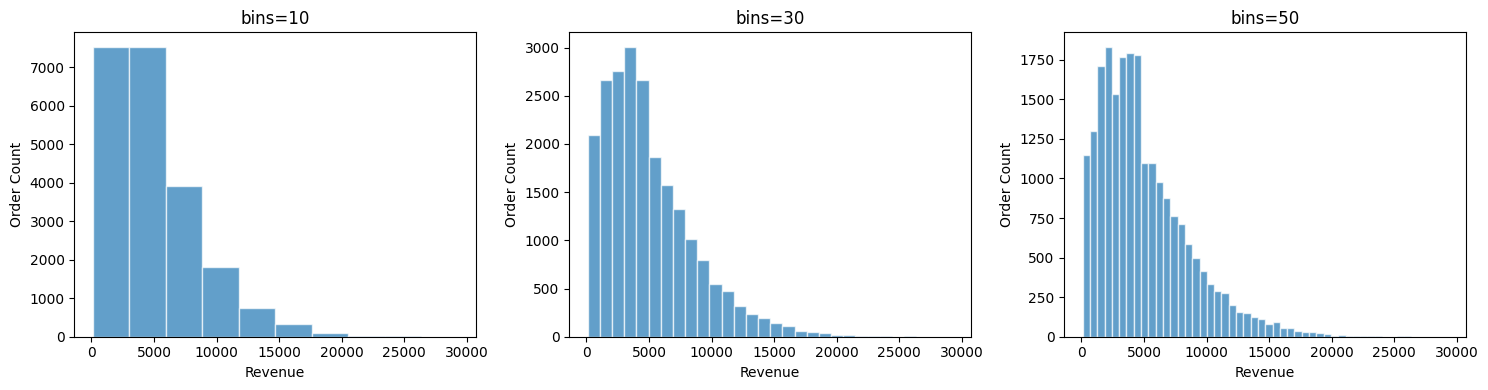

In [ ]:
# 繪製 line_revenue 的直方圖
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 建立 1 列 3 欄的子圖

# 分別用 10、30、50 個 bin 繪製，觀察差異
for ax, b in zip(axes, [10, 30, 50]):     # 迭代每個子圖與對應的 bin 數
    ax.hist(
        order_facts["line_revenue"], # 指定要繪製的欄位
        bins=b, # 設定 bin 數量
        edgecolor="white", # bin 邊框設為白色以利區分
        alpha=0.7  # 透明度 0.7，避免過於濃重
    )
    ax.set_title(f"bins={b}")           # 標題標示 bin 數量
    ax.set_xlabel("Revenue")           # X 軸標籤
    ax.set_ylabel("Order Count")         # Y 軸標籤

plt.tight_layout()                  # 自動調整子圖間距
plt.show()                      # 顯示圖表


**從直方圖判讀偏態（Skewness）**

- **右偏（正偏）**：長尾巴在右邊，代表少數極端高值拉高了平均值。營收資料幾乎都是右偏，因為大多數訂單金額不高，但偶爾有大單。
- **左偏（負偏）**：長尾巴在左邊，較少見，例如考試成績接近滿分時。
- **對稱**：左右大致對稱，例如身高、體重。

判斷偏態的快速方法：若 `mean（平均數） > median（中位數）`，通常為右偏。

### 訂單價值分佈 (密度圖)

密度圖有兩個優點：
- **不受 bin 數量影響**：直方圖換一個 bin 數，形狀就跟著變；密度圖則沒有這個問題。
- **曲線更流暢**：適合用來比較多個群組的分佈形狀（例如：三種裝置的營收分佈疊在同一張圖）。

[機率密度](https://zh.wikipedia.org/zh-tw/%E6%A9%9F%E7%8E%87%E5%AF%86%E5%BA%A6%E5%87%BD%E6%95%B8) (Probability Density)：Y 軸上的數值代表了該 X 軸位置上，資料點的機率密度。


> 簡單來說，它表示在某個特定的營收區間內，資料點（在這裡是訂單營收）出現的可能性有多大。

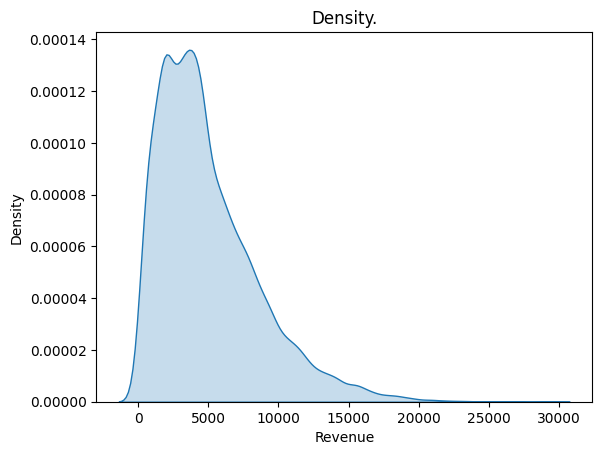

In [ ]:
import seaborn as sns                # 匯入 seaborn 視覺化套件

sns.kdeplot(
    data=order_facts,               # 傳入資料框
    x="line_revenue",               # 指定 X 軸欄位
    fill=True,                   # 填滿曲線下方區域
)                           # 設定填滿區域的透明度
plt.title("Density.")              # 設定圖表標題
plt.xlabel("Revenue")                # X 軸標籤
plt.show()                       # 顯示圖表

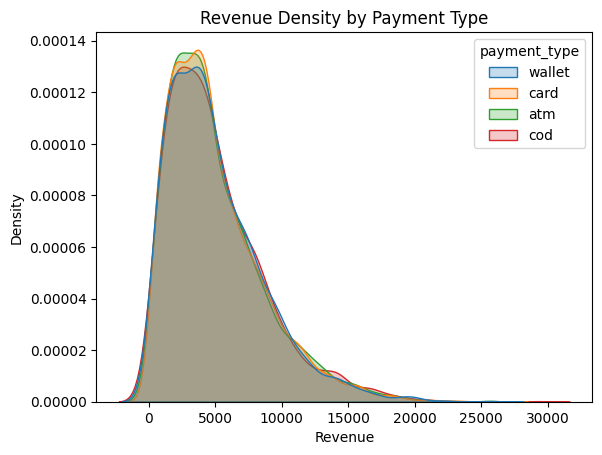

In [ ]:
sns.kdeplot(
    data=order_facts,
    x="line_revenue",
    fill=True,
    hue="payment_type", # 依照付款方式分組
    common_norm=False # 記得做正規化
)
plt.title("Revenue Density by Payment Type")
plt.xlabel("Revenue")
plt.show()

### 訂單價值分佈（箱形圖）
例外：把二維壓縮到一維

```
         ┌─── 最大值（或上鬚末端 = Q3 + 1.5×IQR）
         │
    ─────┤  Q3（第 75 百分位數）
    │    │
    │  ──┤  Q2（中位數，第 50 百分位數）
    │    │
    ─────┤  Q1（第 25 百分位數）
         │
         └─── 最小值（或下鬚末端 = Q1 - 1.5×IQR）

    超過鬚的點 = 離群值（outlier）
```

- **Q1 / Q2 / Q3 是什麼？** 想像把所有訂單金額從小到大排成一排，Q1 是排在最前面 25% 的那個邊界，Q2（中位數）是正中間，Q3 是排在前面 75% 的邊界。換句話說：有一半的訂單落在 Q1 到 Q3 這個箱子裡。
- **IQR（四分位距）** = Q3 − Q1。這就是箱子的高度，代表「中間那 50% 的訂單」涵蓋多大的金額範圍。IQR 越大，箱子越高，表示訂單金額的差異越大；IQR 越小，代表大多數訂單金額很集中。
- **鬚（Whisker）**：從箱子兩端再往外延伸的那兩條線。延伸範圍是 IQR 的 1.5 倍（即 Q1 − 1.5×IQR 到 Q3 + 1.5×IQR）。超出鬚末端的點就被標記為**離群值**，表示那些特別異常的訂單金額。
- 箱子越高（IQR 越大），代表訂單金額的變異性越大。
- 中位線（Q2）偏向箱子的上端或下端，代表資料偏態（偏向哪端就是那個方向的偏態）。

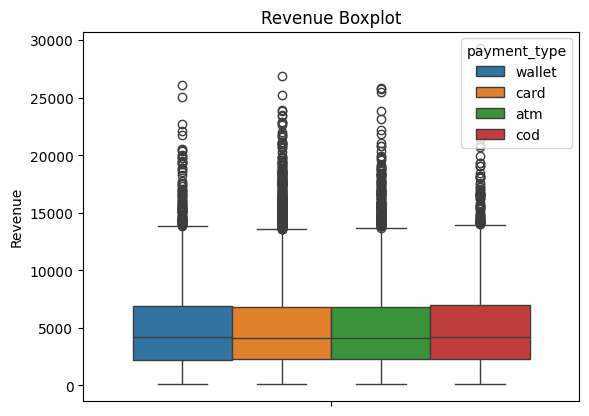

In [ ]:
sns.boxplot(
    data=order_facts,
    hue='payment_type',
    y="line_revenue"
)
plt.title("Revenue Boxplot")
plt.ylabel("Revenue")
plt.show()

## 6-2.關係：X、Y為離散情況
- **正線性**：X 增加，Y 也增加（如：廣告支出 vs. 點擊量）
- **負線性**：X 增加，Y 減少（如：價格 vs. 需求量）
- **非線性**：U 形、對數型（如：工時 vs. 生產力，到達某個閾值後遞減）
- **無關聯**：散佈點呈隨機雲狀（如：顧客身高 vs. 消費金額）
- **異質性**：整體看似無關聯，但分群後各群有明顯趨勢（辛普森悖論）

### 相關矩陣

相關係數（用符號 r 表示）是一個介於 -1 到 +1 之間的數字，告訴你兩個變數「一起變動」的程度與方向：

| r 的值      | 意義                     | 生活範例                   |
| ----------- | ------------------------ | -------------------------- |
| 接近 **+1** | 強正相關：A 大，B 也大   | 廣告費越多，點擊量越高     |
| 接近 **0**  | 無關聯：A 和 B 各走各的  | 顧客身高 vs. 消費金額      |
| 接近 **-1** | 強負相關：A 大，B 反而小 | 商品售價越高，購買人數越少 |

> 實務上的參考準則：`|r| > 0.7` 視為強相關，`0.3 ~ 0.7` 為中度，`< 0.3` 偏弱。

In [ ]:
order_facts

,order_id,customer_id,order_date,status,payment_type,order_month,line_revenue
0,1,2323,2025-05-02,completed,wallet,2025-05,538.65
1,2,117,2024-07-14,completed,wallet,2024-07,4357.70
2,3,160,2025-03-29,cancelled,card,2025-03,3536.00
3,4,1240,2024-07-08,completed,atm,2024-07,1193.40
4,5,714,2024-08-12,completed,atm,2024-08,13175.50
...,...,...,...,...,...,...,...
21995,21996,2390,2025-08-06,completed,card,2025-08,6198.25
21996,21997,2467,2025-10-04,completed,card,2025-10,3160.00
21997,21998,1072,2024-07-05,refunded,cod,2024-07,951.90
21998,21999,1977,2025-03-31,completed,card,2025-03,2204.00


In [ ]:
order_facts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   order_id      22000 non-null  int64    
 1   customer_id   22000 non-null  int64    
 2   order_date    22000 non-null  object   
 3   status        22000 non-null  object   
 4   payment_type  22000 non-null  object   
 5   order_month   22000 non-null  period[M]
 6   line_revenue  22000 non-null  float64  
dtypes: float64(1), int64(2), object(3), period[M](1)
memory usage: 1.2+ MB


### 訂單項目數值關係的相關矩陣

由於單一變數的相關係數永遠是 1，沒有分析價值。為了探索更多變數之間的關係，我們可以使用 `order_items_df` 中的數值欄位，例如 `quantity` (數量)、`unit_price` (單價)、`discount_rate` (折扣率) 和 `line_revenue` (單行營收)，來計算它們之間的 Pearson 相關係數。

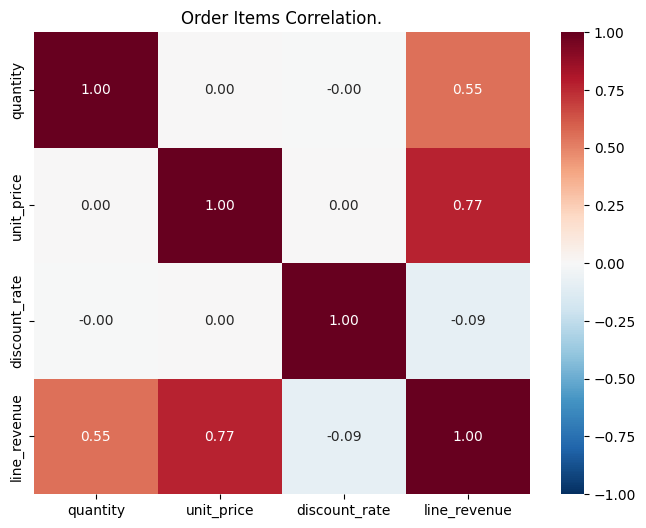

In [ ]:
cols_for_corr = ['quantity', 'unit_price', 'discount_rate', 'line_revenue']
corr_matrix_items = order_items_df[cols_for_corr].corr() # 計算 Pearson 相關矩陣

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_items,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1, center=0
)
plt.title("Order Items Correlation.") # 設定標題
plt.show()

**相關 ≠ 因果（Correlation ≠ Causation）**
> 冰淇淋銷量與溺水人數高度正相關，但吃冰淇淋不會導致溺水。兩者都受到「夏天」這個混淆變數的驅動。

> 在商業場景中，看到相關性時，需要考慮：「有沒有第三個變數同時影響這兩者？」只有透過實驗或釐清，才能建立因果推論。


## 6-3.分群對比：X為離散、Y為連續

* 分群長條圖（Grouped Bar Chart）
    * 分群長條圖是比較不同群組之間數值差異的經典圖表，每個群組（如：客群）會有多個長條（如：裝置類型），並排顯示，讓你直接比較同一客群在不同裝置上的營收表現。
* 並列箱形圖（Side-by-Side Boxplots）
    * 並列箱形圖是比較不同群組分佈差異的利器，每個群組（如：客群）會有一個箱形圖，並排顯示，讓你不只比較中位數，還能看到變異程度與離群值情況。
* 時間序列折線圖
    * 時間序列折線圖適合比較不同群組在時間軸上的趨勢變化，例如：各客群的月營收趨勢。每個群組會有一條折線，讓你直接比較不同客群的成長軌跡。

### 分組長條圖-客群 & 付款方式 & 訂單量

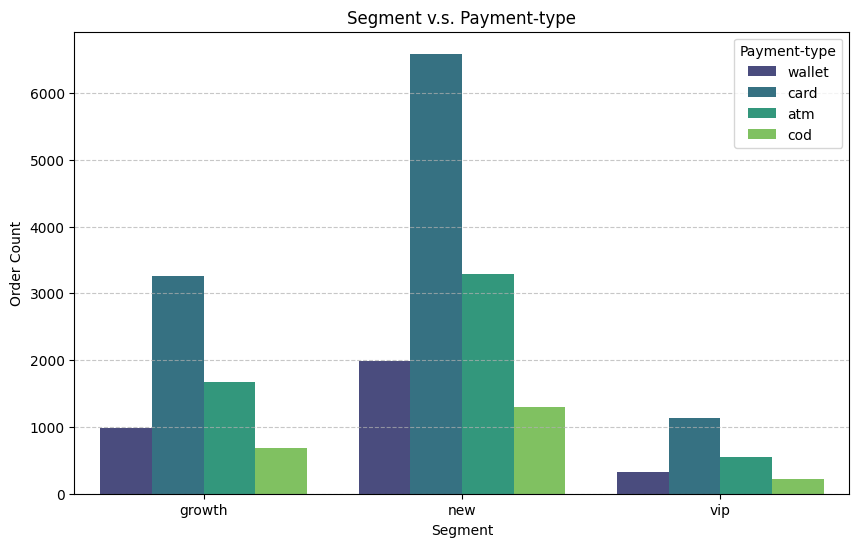

In [ ]:
merged_df = order_df.merge(customers_df, on='customer_id', how='left')

plt.figure(figsize=(10, 6))
sns.countplot(
    data=merged_df,
    x='segment', # 分組
    hue='payment_type', # 組內的長條圖有哪些
    palette='viridis'
)
plt.title('Segment v.s. Payment-type')
plt.xlabel('Segment')
plt.ylabel('Order Count')
plt.legend(title='Payment-type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 分組長條圖-客群 & 付款方式 & 總營收

In [ ]:
merged_df = order_df.merge(customers_df, on='customer_id', how='left')
merged_df = merged_df.merge(order_items_df[['order_id', 'line_revenue']], on='order_id', how='left')

# 計算每個客群和付款方式組合的總營收
revenue_by_segment_payment = merged_df.groupby(['segment', 'payment_type'])['line_revenue'].sum().reset_index()

In [ ]:
revenue_by_segment_payment

,segment,payment_type,line_revenue
0,growth,atm,8232366.25
1,growth,card,16545069.30
2,growth,cod,3496811.00
3,growth,wallet,4856996.70
4,new,atm,16429592.25
5,new,card,32285018.90
6,new,cod,6514328.75
7,new,wallet,9877765.30
8,vip,atm,2832946.45
9,vip,card,5763897.80


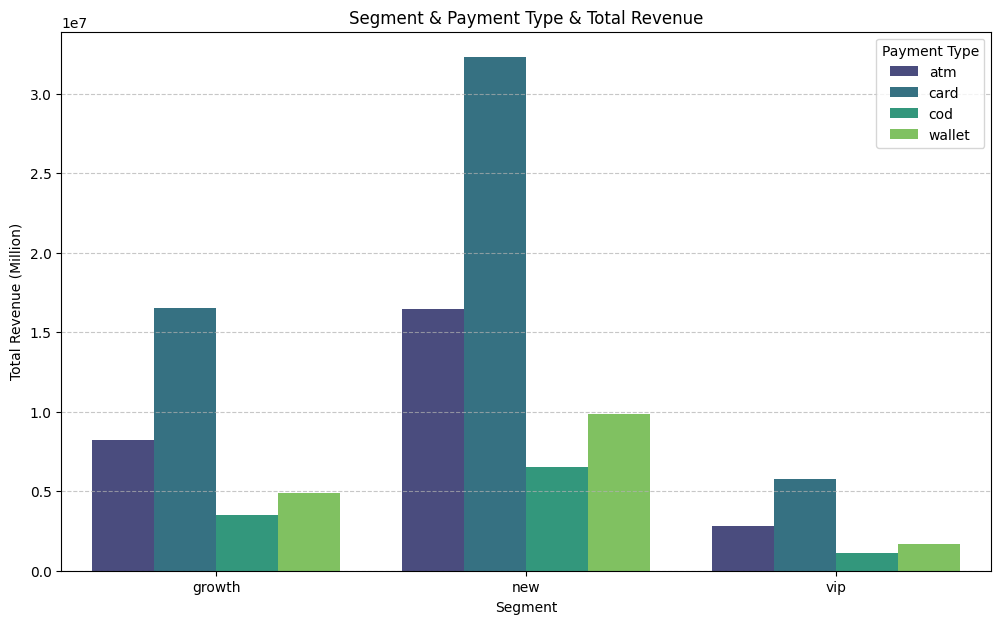

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=revenue_by_segment_payment,
    x='segment',
    y='line_revenue',
    hue='payment_type',
    palette='viridis' # 可以選擇不同的調色盤
)
plt.title('Segment & Payment Type & Total Revenue')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (Million)')
plt.legend(title='Payment Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 箱型圖-客群 & 付款方式 & 總營收

In [ ]:
# 1. 計算每個訂單的總營收
order_total_revenue = (
    order_items_df.groupby('order_id')['line_revenue']
    .sum()
    .reset_index()
)
order_total_revenue.rename(columns={'line_revenue': 'total_order_revenue'}, inplace=True)

# 2. 合併 orders 和 customers 以取得 segment 和 payment_type
order_level_df = order_df.merge(customers_df, on='customer_id', how='left')

# 3. 再將總營收合併到這個 DataFrame
order_level_df = order_level_df.merge(order_total_revenue, on='order_id', how='left')

display(order_level_df.head())

,order_id,customer_id,order_date,status,payment_type,order_month,signup_date,acquisition_channel,city,segment,total_order_revenue
0,1,2323,2025-05-02,completed,wallet,2025-05,2023-10-19,referral,Taipei,growth,538.65
1,2,117,2024-07-14,completed,wallet,2024-07,2024-09-19,organic,Kaohsiung,new,4357.70
2,3,160,2025-03-29,cancelled,card,2025-03,2024-02-04,social,Hsinchu,new,3536.00
3,4,1240,2024-07-08,completed,atm,2024-07,2023-02-09,ads,Taichung,new,1193.40
4,5,714,2024-08-12,completed,atm,2024-08,2023-01-24,partner,Hsinchu,growth,13175.50


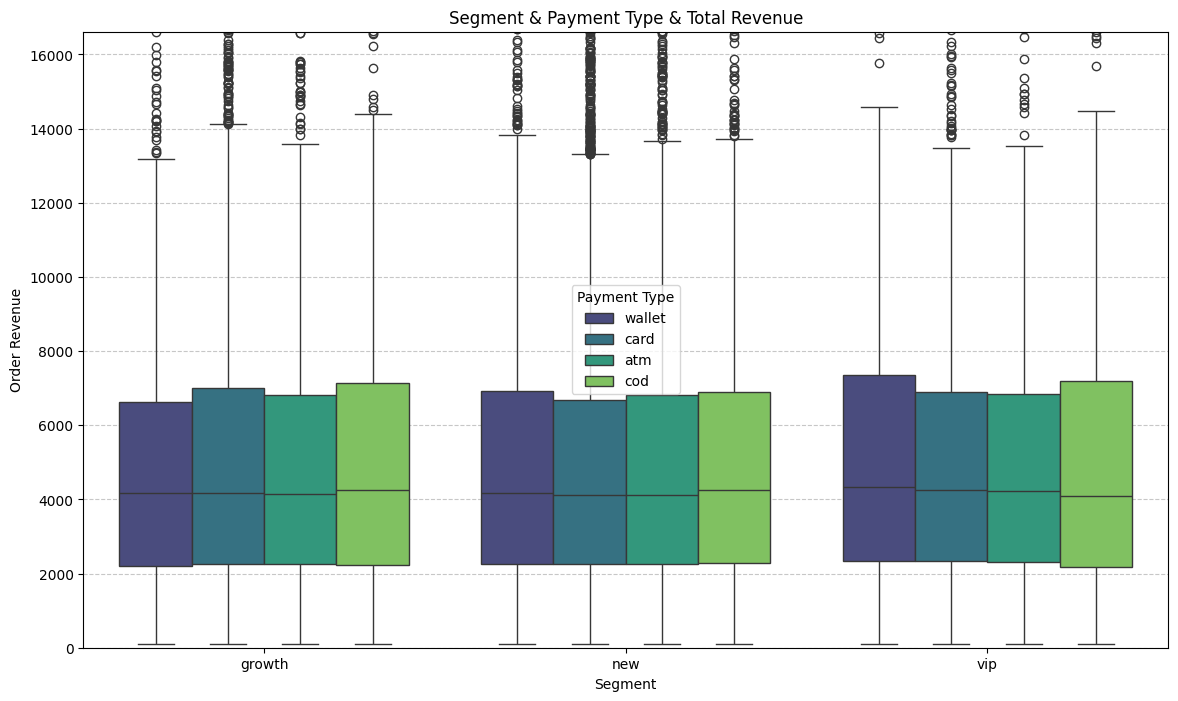

In [ ]:

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=order_level_df, # 使用訂單層級的數據
    x='segment',
    y='total_order_revenue', # Y軸顯示訂單總營收
    hue='payment_type',
    palette='viridis'
)
plt.title('Segment & Payment Type & Total Revenue')
plt.xlabel('Segment')
plt.ylabel('Order Revenue')
plt.legend(title='Payment Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, order_level_df['total_order_revenue'].quantile(0.99)) # 限制Y軸，去除極端離群值以更好地觀察主體分佈
plt.show()

## 6-4.時間序列折線圖-客群營收趨勢

In [ ]:
order_level_df

,order_id,customer_id,order_date,status,payment_type,order_month,signup_date,acquisition_channel,city,segment,total_order_revenue
0,1,2323,2025-05-02,completed,wallet,2025-05,2023-10-19,referral,Taipei,growth,538.65
1,2,117,2024-07-14,completed,wallet,2024-07,2024-09-19,organic,Kaohsiung,new,4357.70
2,3,160,2025-03-29,cancelled,card,2025-03,2024-02-04,social,Hsinchu,new,3536.00
3,4,1240,2024-07-08,completed,atm,2024-07,2023-02-09,ads,Taichung,new,1193.40
4,5,714,2024-08-12,completed,atm,2024-08,2023-01-24,partner,Hsinchu,growth,13175.50
...,...,...,...,...,...,...,...,...,...,...,...
21995,21996,2390,2025-08-06,completed,card,2025-08,2024-08-06,referral,Tainan,new,6198.25
21996,21997,2467,2025-10-04,completed,card,2025-10,2023-09-12,social,Taoyuan,new,3160.00
21997,21998,1072,2024-07-05,refunded,cod,2024-07,2023-03-20,organic,Kaohsiung,vip,951.90
21998,21999,1977,2025-03-31,completed,card,2025-03,2022-12-16,organic,Taipei,new,2204.00


/tmp/ipykernel_1853/4255170636.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Segment')


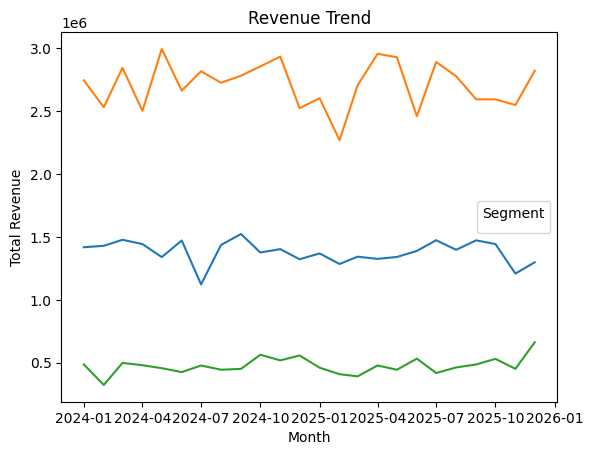

In [ ]:
monthly = (
    order_level_df
    .groupby(['order_month', 'segment'])['total_order_revenue']  # 按月份×客群分組
    .sum()                             # 加總營收
    .unstack('segment')
)

# 將 order_month 索引轉換為 datetime
monthly.index = monthly.index.to_timestamp() # 將 PeriodIndex 轉換為 DateTimeIndex
plt.plot(
    monthly.index,       # x
    monthly[monthly.columns],  # y
)
plt.title('Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.legend(title='Segment')
plt.show()

# 7.視覺化關鍵洞察

技術人員的圖表通常資訊密度高，但管理層需要的是「3 秒看懂」。轉化原則：

1. **標題寫結論**：「VIP 營收是新客 4.1 倍」而非「Revenue by Segment」。
2. **移除格線與多餘裝飾**：`sns.despine()` 移除上方與右方邊框。
3. **標註關鍵數字**：在長條上方加數字標籤。
4. **限制顏色數量**：同一張圖不超過 4 種顏色，重點用強調色。
5. **加上行動建議**：在圖表下方或旁邊加上一句「So what?」。


| 層次                  | 問題                 | 範例                                       |
| --------------------- | -------------------- | ------------------------------------------ |
| **Data（資料層）**    | 圖表呈現了什麼數據？ | VIP 客群中位數營收 2,800 元，新客群 680 元 |
| **Message（訊息層）** | 這代表什麼含義？     | VIP 的單筆消費力是新客的 4 倍              |
| **Action（行動層）**  | 我們應該怎麼做？     | 投入更多資源培養 growth → VIP 的升級路徑   |

> 每張圖表要表達 **Data → Message → Action** 三層結構。

> 圖表畫得再漂亮，如果底層資料有問題，結論就會全盤走鐘皆錯（garbage in, garbage out）。

# 8.( 進階 ) 統計學知識

1. 區分母體（Population）與樣本（Sample），理解為何需要從樣本推論母體。
2. 理解抽樣分佈（Sampling Distribution）的概念與直覺。
3. 用白話文解釋中央極限定理（CLT），知道它的前提條件與重要性。
4. 區分點估計（Point Estimate）與區間估計（Interval Estimate）。
5. 正確解讀信賴區間（Confidence Interval），並能辨識常見的錯誤解讀。
6. 理解 Bootstrap 的原理、步驟、適用時機，並能用 Python 實作。
7. 能將信賴區間的結果轉化為 PM 可閱讀的備忘錄。


## 8-1.母體與樣本

- **母體（Population）**：你想推論的完整對象集合。例如：「所有曾經或未來會在我們平台消費的顧客」。
- **樣本（Sample）**：你實際擁有的資料子集。例如：「2024 年 1 月到 6 月在我們平台下單的 5,000 位顧客」。


**為什麼不直接分析母體？**
大多數情況下，你無法取得母體的完整資料，譬如說：
- 未來的訂單、客戶還沒出現。
- 潛在顧客中還沒消費的人你看不到。

因此，我們別無選擇，只能從手上的樣本出發，對母體做出推論，但是推論就會有不確定性，我們的核心任務就是量化這個不確定性。



|        | 母體             | 樣本               |
| ------ | ---------------- | ------------------ |
| 平均值 | μ（mu，未知）    | x̄（x-bar，可計算） |
| 標準差 | σ（sigma，未知） | s（可計算）        |
| 比例   | p（未知）        | p̂（p-hat，可計算）


## 8-2.抽樣

我們用樣本的統計量來「估計」母體的參數。但每次抽樣得到的統計量不會完全一樣，這就帶出了抽樣分佈的概念。

用具體的例子來理解這句話：

假設你想知道平台「所有訂單」的平均營收（母體平均值 μ），但你只能抽取 100 筆訂單來計算樣本平均值 x̄。

- **第一次抽樣**：你的 100 筆訂單碰巧抽到幾筆大單，算出 x̄ = 1,320 元。
- **第二次抽樣**：換一批 100 筆，這次沒那麼幸運，算出 x̄ = 1,190 元。
- **第三次抽樣**：又換一批，算出 x̄ = 1,260 元。

> 每次抽樣的結果不同，但都是對同一個 μ 的估計。這些「每次抽樣算出來的 x̄」本身也有一個分佈——**它們落在哪個範圍？集中還是分散？呈現什麼形狀？**，這就是「抽樣分佈」要回答的問題。

> 換句話說：統計量（如 x̄）不是一個固定的數，而是一個**會隨抽樣結果變動的隨機變數**，而抽樣分佈就是描述這個隨機變數的行為。理解抽樣分佈，才能知道你的估計「有多可靠」、「可能偏差多少」。


想像你可以無限次重複以下實驗：

1. 從母體中隨機抽出 100 筆訂單。
2. 計算這 100 筆訂單的平均營收。
3. 把這個平均值記下來。

重複 10,000 次後，你手上有 10,000 個「樣本平均值」。把這 10,000 個平均值畫成直方圖，這就是「樣本平均值的抽樣分佈」。

這個分佈告訴你：同樣是從母體抽 100 筆，你每次得到的平均值會有多大的變動範圍。

## 8-3.中央極限定理（Central Limit Theorem, CLT）

> 不管原始資料的分佈長什麼樣子（右偏、左偏、雙峰、均勻），只要樣本量夠大，樣本平均值的抽樣分佈就會趨近常態分佈（鐘形曲線）。


> 這是統計學中最神奇的定理，它讓我們可以用常態分佈的數學性質（如 z 值、百分位數）來建構信賴區間，即使原始資料一點都不像常態分佈。

**為什麼這件事令人驚訝？**

電商平台的訂單金額分佈，長相通常非常醜：絕大多數訂單可能只有幾百元，但偶爾出現幾筆幾萬元的大單，整個分佈是嚴重右偏的，完全不像鐘形曲線。

但 CLT（中央極限定理） 告訴你：**就算原始資料歪成這樣，只要你每次抽大於等於 30 筆來算平均值，重複很多次之後，這些「樣本平均值」的分佈就會自動變成鐘形曲線。**

1. 想像你手上有全平台 10 萬筆訂單（分佈嚴重偏態）。
2. 你隨機抽 100 筆，算出平均值 x̄₁ = 1,250 元。
3. 再抽一批 100 筆，算出 x̄₂ = 1,310 元。
4. 重複 10,000 次，你得到 10,000 個 x̄。
5. 把這 10,000 個 x̄ 畫成直方圖，你會發現它長得像鐘形曲線，即使原始訂單資料完全不是！

這就是 CLT 的神奇之處：它把「雜亂的原始分佈」轉換成「規律的鐘形分佈」，讓我們可以套用常態分佈的數學工具。


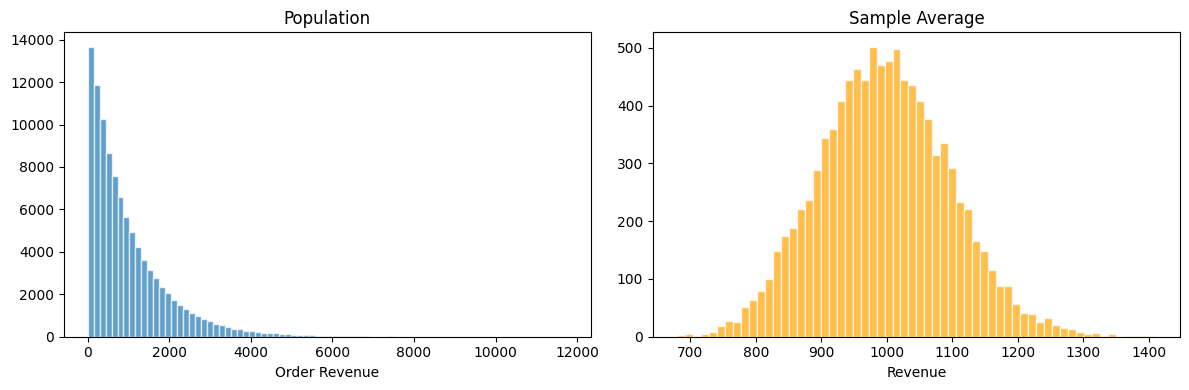

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 模擬「嚴重偏態」的訂單金額（用指數分佈）
np.random.seed(42)
population = np.random.exponential(scale=1000, size=100_000)  # 右偏分佈

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左圖：原始資料的分佈
axes[0].hist(population, bins=80, edgecolor="white", alpha=0.7)
axes[0].set_title("Population")
axes[0].set_xlabel("Order Revenue")

# 右圖：抽樣平均值的分佈（CLT 發揮作用）
sample_means = [
    np.random.choice(population, size=100).mean()   # 每次抽 100 筆取平均
    for _ in range(10_000)             # 重複 10,000 次
]
axes[1].hist(sample_means, bins=60, edgecolor="white", alpha=0.7, color="orange")
axes[1].set_title("Sample Average")
axes[1].set_xlabel("Revenue")

plt.tight_layout()
plt.show()
# 左圖很醜、右偏；右圖自動變成漂亮的鐘形曲線，這就是 CLT

前提條件
1. **獨立性**：每筆觀測值是獨立的（一位顧客的行為不影響另一位）。
2. **樣本量足夠大**：經驗法則是 n ≥ 30，但如果原始分佈非常偏態，可能需要更大的 n。
3. **有限的變異數**：母體的變異數不能是無限大。

CLT 之所以被稱為「現代統計推論的基石」，原因很簡單：

- 現實中的資料幾乎不會剛好是常態分佈。訂單金額右偏、用戶停留時間右偏、退貨率趨近 0 的偏態，這些都是常見情況。
- 但只要樣本量夠大，你算出來的樣本平均值就會「表現得像」常態分佈。
- 這讓你可以直接使用常態分佈的公式（z 值、標準誤）來計算信賴區間，**不需要知道原始資料是什麼分佈**。

簡單說：「即使我不知道母體長什麼樣子，只要樣本夠大，我就可以放心的用常態分佈的工具來做推論。」，這就是你能信任信賴區間公式的根本原因。


# 9.交付參考

| 面向       | 包含內容                         | 對應受眾           |
| ---------- | -------------------------------- | ------------------ |
| 問題定義   | 商業背景、分析目標、成功指標     | PM、主管           |
| 資料說明   | 資料來源、Schema、資料品質報告   | 資料工程師、分析師 |
| 分析過程   | EDA、統計分析、A/B Test、ML 建模 | 資料科學家         |
| 結論與建議 | 關鍵發現、行動建議、限制說明     | 所有利害關係人     |
| 可重現性   | 環境設定、執行步驟、隨機種子     | 任何想重現的人     |



## 9-1.最終交付物清單

> README 是專案的門面，決定了別人是否願意繼續閱讀。一份好的 README 應包含：


1. 專案概述
    * 本專案分析某電商平台的使用者行為數據
    * 涵蓋訂單分析、顧客分群、客戶行為紀錄。
2. 資料來源
    * 七張資料表：
        > sessions, events, orders, order_items, customers, products, ab_assignments
    * 資料期間：
        > YYYY/MM/DD - YYYY/MM/DD
    * 總筆數：
        > sessions ___筆, events ___筆, orders ___筆
3. 主要發現
    * 行動裝置的轉換率較桌面低 40%，建議優化行動版結帳流程
    * VIP 客群佔營收 35%，但回購率呈下降趨勢
    * 購買預測模型達到可用區分能力（AUC 約 0.69），最重要特徵為..
4. KPI總表
    * 營收指標
        * 總營收 (Total Revenue)
        * 已完成訂單數
        * 平均客單價 (AOV)

    * 轉換指標
        * 整體轉換率(%)
        * Mobile 轉換率(%)
        * Desktop 轉換率(%)

    * 顧客指標
        * 總顧客數
        * VIP 顧客佔比(%)
        * 新客 30 日留存率(%)

    * 模型表現
        * Baseline (LR) AUC
        * Best Model (RF) AUC
        * 最重要特徵

## 9-2.簡報設計原則

控制在10-20分鐘內完成，無法當下回答的問題要擱置或在會後處理

1. **一頁一個重點**：不要在一頁投影片上塞太多資訊
2. **圖表 > 表格 > 文字**：視覺化是最快傳達資訊的方式
3. **標題即結論**：投影片標題不要寫「轉換率分析」，要寫「行動裝置轉換率比桌面低 40%」
4. **附上信心程度**：對於不確定的發現，誠實標註「初步觀察」或「需要更多數據驗證」

## 9-3.常見簡報錯誤

- 花太多時間在 **「我怎麼做的」** 而非 **「我發現了什麼」**
- **展示太多程式碼**
- 沒有給出建議
- 超時（嚴格遵守時間限制是專業的表現）

## 9-4.軟技能：
1. **資料敘事**：分析結果若無法有效溝通，就分析本身的價值有限。
2. **受眾意識**：同樣的分析結果，對 CEO 和工程師的呈現方式截然不同
3. **知道何時停止**：不是所有優化都值得做，懂得在「夠好」時停下來
